<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
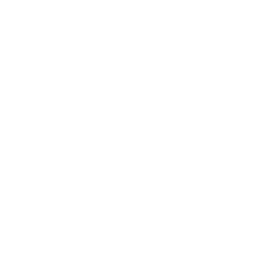
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Codage des événements indésirables d'un essai clinique</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutique / Pharmacovigilance &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Synthèse

Les jeux de données d'événements indésirables arrivent avec les termes préférés
MedDRA verbatim, mais les tableaux de sécurité réglementaires sont organisés par
classe de systèmes d'organes (SOC). Cet exemple construit un format de valeurs
PROC FORMAT qui associe chaque terme préféré à sa SOC, puis utilise ce format
unique pour piloter toutes les tabulations en aval : un tableau croisé PROC FREQ
de la SOC par bras de traitement, une ventilation SOC par sévérité, et une
synthèse des événements indésirables graves. Comme le mappage ne réside que
dans le format, recoder l'essai vers une nouvelle version MedDRA se résume à
modifier un seul format plutôt qu'à réécrire chaque rapport. ODS OUTPUT capture
les fréquences par SOC sous forme de jeu de données pour la revue de signal en
aval.


## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------:|
| WORK.AE_RAW | Enregistrements synthétiques d'événements indésirables avec termes préférés MedDRA | 100 |
| WORK.RANDOMIZATION | Attributions du bras de traitement des sujets | 100 |

L'environnement s'exécute en mode non licencié, si bien que chaque table
générée est plafonnée à 100 observations. Le scénario est dimensionné en
conséquence : 100 événements indésirables tirés d'un panel MedDRA de 12 termes
typique d'un essai en oncologie.


---

In [1]:
/* --------------------------------------------------------
   Générer un jeu de données synthétique d'événements indésirables
   Termes préférés MedDRA associés aux catégories SOC
   -------------------------------------------------------- */
DONNÉES work.ae_raw;
    APPELER streaminit(42);
    LONGUEUR aedecod $40 aesev $10;
    TABLEAU pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    FAIRE i = 1 JUSQU_À 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', ÉCRIRE(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        SI pt_idx = 1 ALORS aedecod = 'Nausées';
        SINON SI pt_idx = 2 ALORS aedecod = 'Céphalée';
        SINON SI pt_idx = 3 ALORS aedecod = 'Vomissements';
        SINON SI pt_idx = 4 ALORS aedecod = 'Diarrhée';
        SINON SI pt_idx = 5 ALORS aedecod = 'Toux';
        SINON SI pt_idx = 6 ALORS aedecod = 'Fatigue';
        SINON SI pt_idx = 7 ALORS aedecod = 'Arthralgie';
        SINON SI pt_idx = 8 ALORS aedecod = 'Pyrexie';
        SINON SI pt_idx = 9 ALORS aedecod = 'Douleur abdominale';
        SINON SI pt_idx = 10 ALORS aedecod = 'Neutropénie';
        SINON SI pt_idx = 11 ALORS aedecod = 'Neutropénie fébrile';
        SINON aedecod = 'Réaction liée à la perfusion';
        sev_idx = int(rand('uniform') * 3) + 1;
        SI pt_idx DANS (10, 11) ALORS sev_idx = MAX(sev_idx, 2);
        SI sev_idx = 1 ALORS aesev = 'Léger';
        SINON SI sev_idx = 2 ALORS aesev = 'Modéré';
        SINON aesev = 'Sévère';
        aeser = ifc(aesev = 'Sévère' AND rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        SI aestdy > 365 ALORS aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', ÉCRIRE(int(rand('uniform') * 25) + 1, z3.));
        SORTIE;
    FIN;
    SUPPRIMER i pt_idx sev_idx;
EXÉCUTER;



NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.73 seconds
  cpu   1.73 seconds


In [2]:
/* --------------------------------------------------------
   Générer la table de randomisation des sujets
   -------------------------------------------------------- */
DONNÉES work.randomization;
    APPELER streaminit(43);
    TABLEAU arms[3] $20 _temporary_ ('EXPERIMENTAL' 'COMPARATEUR_ACTIF' 'PLACEBO');
    FAIRE subject_id = 1 JUSQU_À 800;
        usubjid = cat('ONC-2025-', ÉCRIRE(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arms[arm_idx];
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        SORTIE;
    FIN;
    SUPPRIMER arm_idx;
    format randomization_date date9.;
EXÉCUTER;



NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---

                                    Fréquence brute des termes préférés (non mappés)                                    

                                                   The FREQ Procedure

Terme préféré                      Frequency    Percent
--------------------------------------------------------
Céphalée                                  12     12.00
Diarrhée                                  12     12.00
Fatigue                                   11     11.00
Pyrexie                                   11     11.00
Arthralgie                                10     10.00
Nausées                                   10     10.00
Réaction liée à la perfusion               8      8.00
Toux                                       7      7.00
Douleur abdominale                         5      5.00
Neutropénie                                5      5.00
Neutropénie fébrile                        5      5.00
Vomissements                               4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


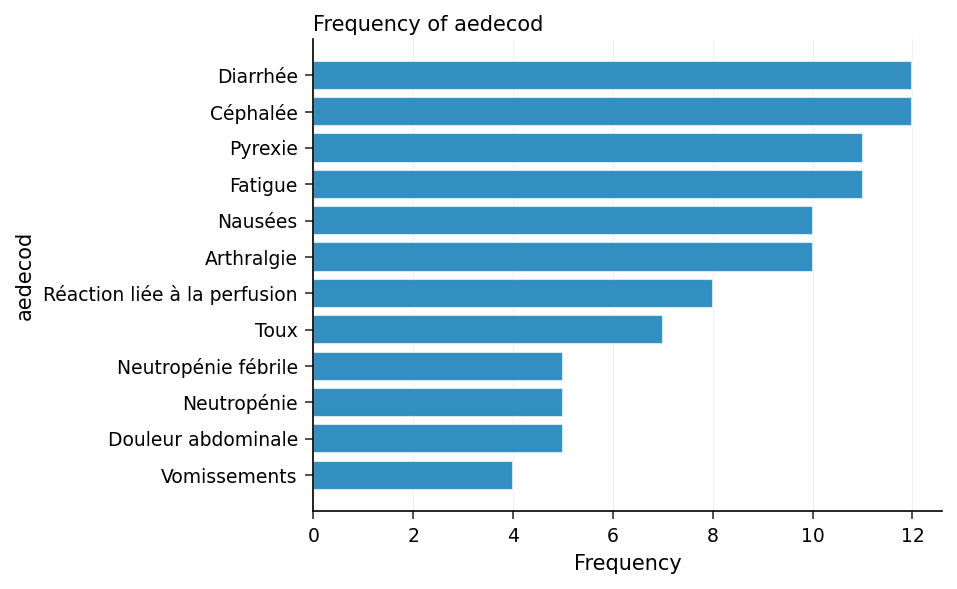

In [3]:
/* --------------------------------------------------------
   Fréquence de référence des termes préférés avant mappage SOC
   -------------------------------------------------------- */
PROCÉDURE FRÉQUENCES DONNÉES=work.ae_raw ORDRE=FRÉQUENCES;
    TABLES aedecod / nocum;
    ÉTIQUETTE aedecod='Terme préféré';
    TITRE 'Fréquence brute des termes préférés (non mappés)';
EXÉCUTER;


---

                                    Fréquence brute des termes préférés (non mappés)                                    




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


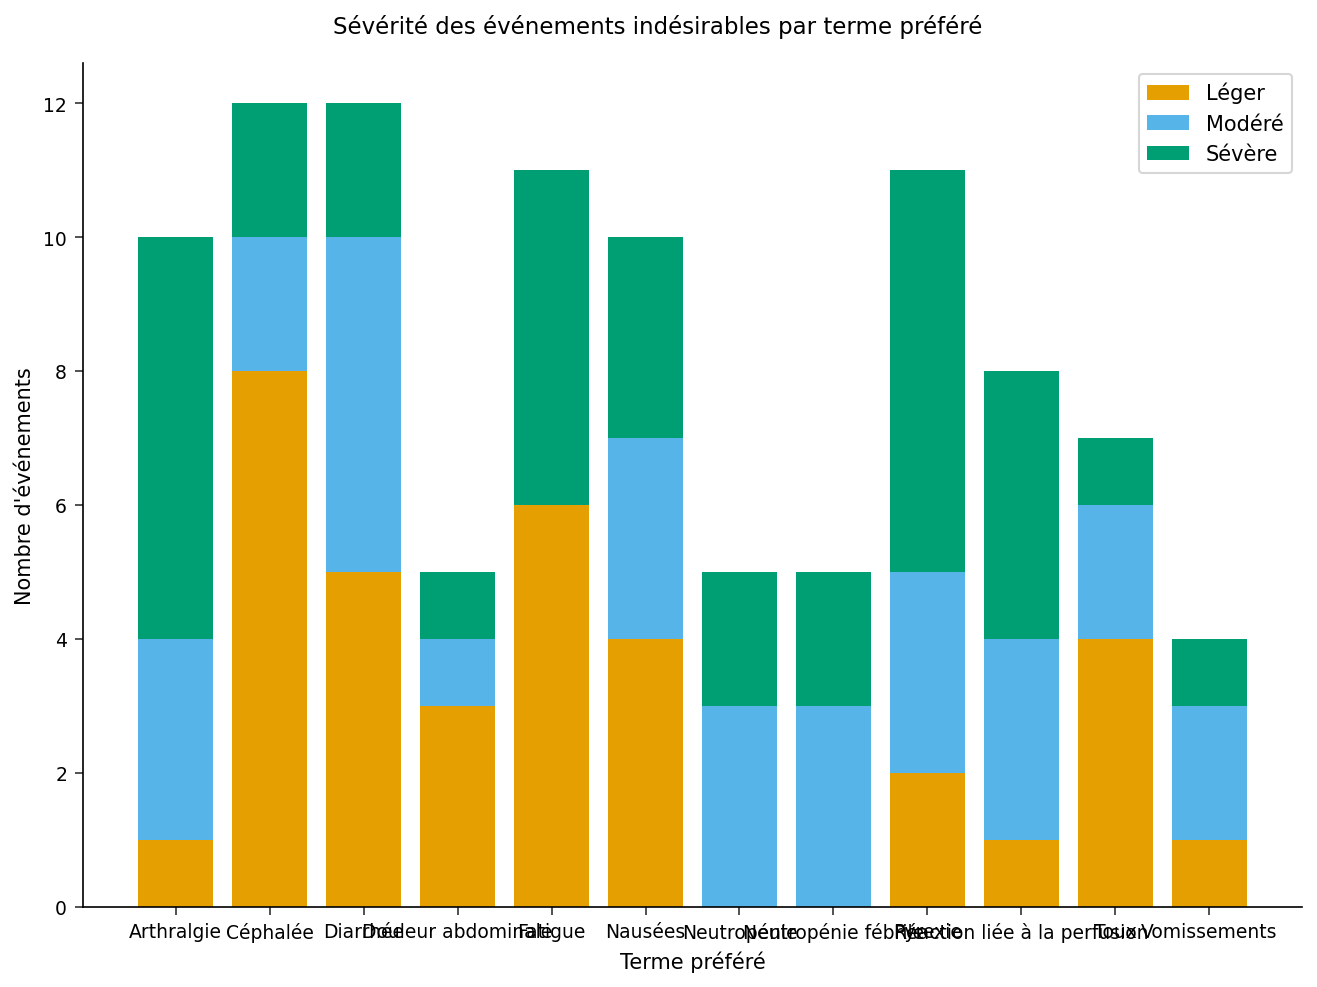

In [4]:
/* --------------------------------------------------------
   Répartition de la sévérité des EI par terme préféré
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.ae_raw;
    VBAR aedecod / GROUPE=aesev GROUPDISPLAY=stack;
    XAXIS ÉTIQUETTE='Terme préféré' fitpolicy=ROTATE;
    YAXIS ÉTIQUETTE="Nombre d'événements";
    TITRE 'Sévérité des événements indésirables par terme préféré';
EXÉCUTER;


---

In [5]:
/* --------------------------------------------------------
   Définir le format de valeurs terme préféré MedDRA -> classe
   de systèmes d'organes. Le format est indexé sur le texte du
   terme préféré, si bien qu'un seul appel PUT() code tout
   enregistrement d'EI vers sa SOC.
   -------------------------------------------------------- */
PROCÉDURE format;
    VALEUR $pt_to_soc
        'Nausées'                      = 'Affections gastro-intestinales'
        'Vomissements'                  = 'Affections gastro-intestinales'
        'Diarrhée'                      = 'Affections gastro-intestinales'
        'Douleur abdominale'            = 'Affections gastro-intestinales'
        'Céphalée'                      = 'Affections du système nerveux'
        'Fatigue'                       = 'Troubles généraux'
        'Pyrexie'                       = 'Troubles généraux'
        'Toux'                          = 'Affections respiratoires'
        'Arthralgie'                    = 'Affections musculo-squelettiques'
        'Neutropénie'                   = 'Affections hématologiques et du système lymphatique'
        'Neutropénie fébrile'           = 'Affections hématologiques et du système lymphatique'
        'Réaction liée à la perfusion'  = 'Affections du système immunitaire'
        OTHER                           = 'Non codé'
    ;
    VALEUR $sev_rank
        'Léger'   = '1-Léger'
        'Modéré'  = '2-Modéré'
        'Sévère'  = '3-Sévère'
        OTHER     = '9-Inconnu'
    ;
    VALEUR $serious_fmt
        'Y' = 'Grave'
        'N' = 'Non grave'
    ;
EXÉCUTER;



NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Fusionner les enregistrements d'EI avec le bras de
   traitement, puis appliquer le format SOC. PUT(aedecod,
   $pt_to_soc.) est la seule étape de mappage nécessaire ;
   la sévérité et la gravité sont codées de la même façon.
   -------------------------------------------------------- */
PROCÉDURE TRIER DONNÉES=work.ae_raw; PAR usubjid; EXÉCUTER;
PROCÉDURE TRIER DONNÉES=work.randomization; PAR usubjid; EXÉCUTER;

DONNÉES work.ae_coded;
    FUSIONNER work.ae_raw (DANS=a)
          work.randomization (DANS=b GARDER=usubjid treatment_arm);
    PAR usubjid;
    SI a;
    soc_class     = ÉCRIRE(aedecod, $pt_to_soc.);
    severity_rank = ÉCRIRE(aesev,   $sev_rank.);
    serious_flag  = ÉCRIRE(aeser,   $serious_fmt.);
EXÉCUTER;



NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


                        Incidence des EI par classe de systèmes d'organes et bras de traitement                         

                                                   The FREQ Procedure

Table of Classe de systèmes d'organes (SOC) by Bras de traitement

Classe de systèmes d'organes (SOC)                    |COMPARATEUR_ACTIF |     EXPERIMENTAL |          PLACEBO |             Total
------------------------------------------------------+------------------+------------------+------------------+------------------
Affections du système immunitaire                     |                0 |                1 |                1 |                 2
------------------------------------------------------+------------------+------------------+------------------+------------------
Affections gastro-intestinales                        |                1 |                0 |                2 |                 3
------------------------------------------------------+------------------+-----------


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


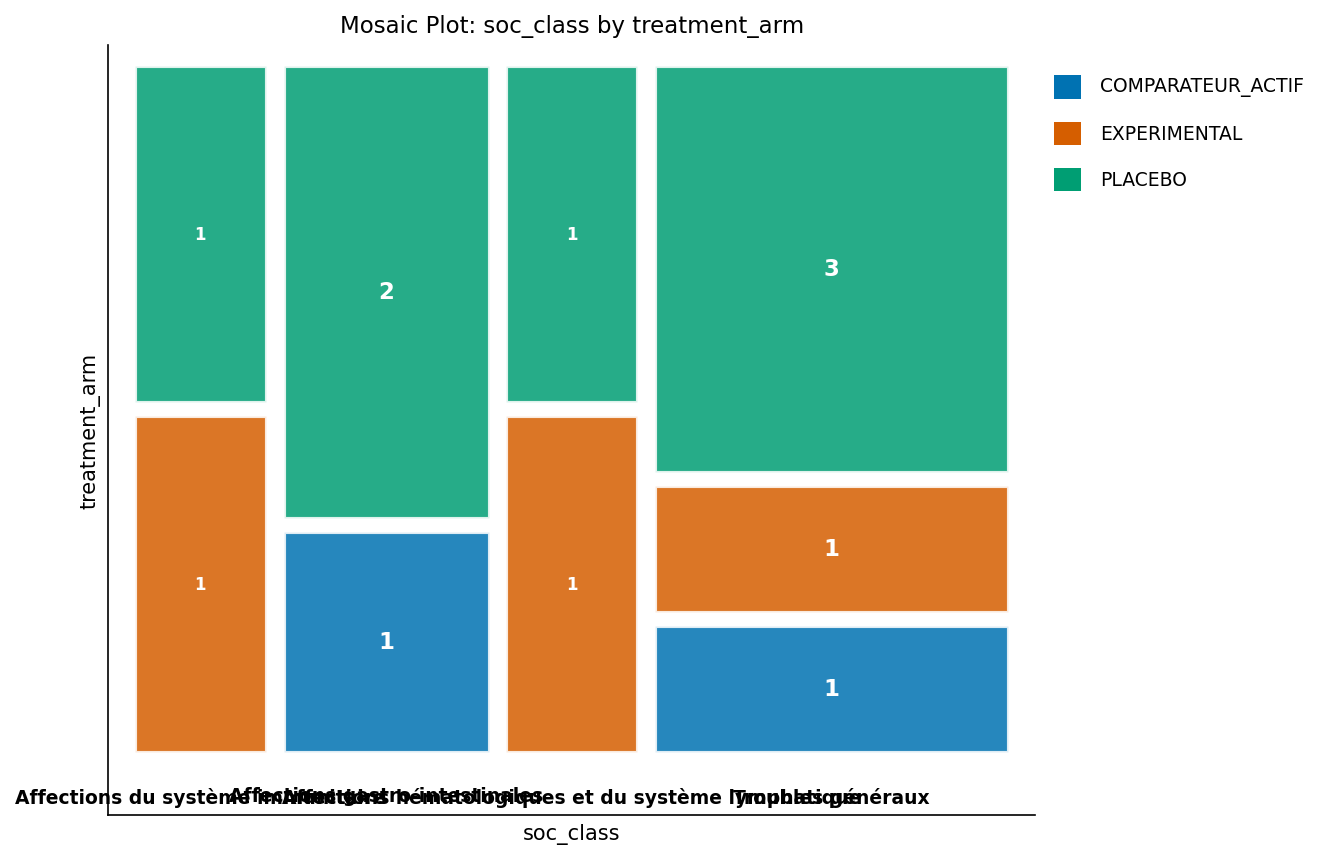

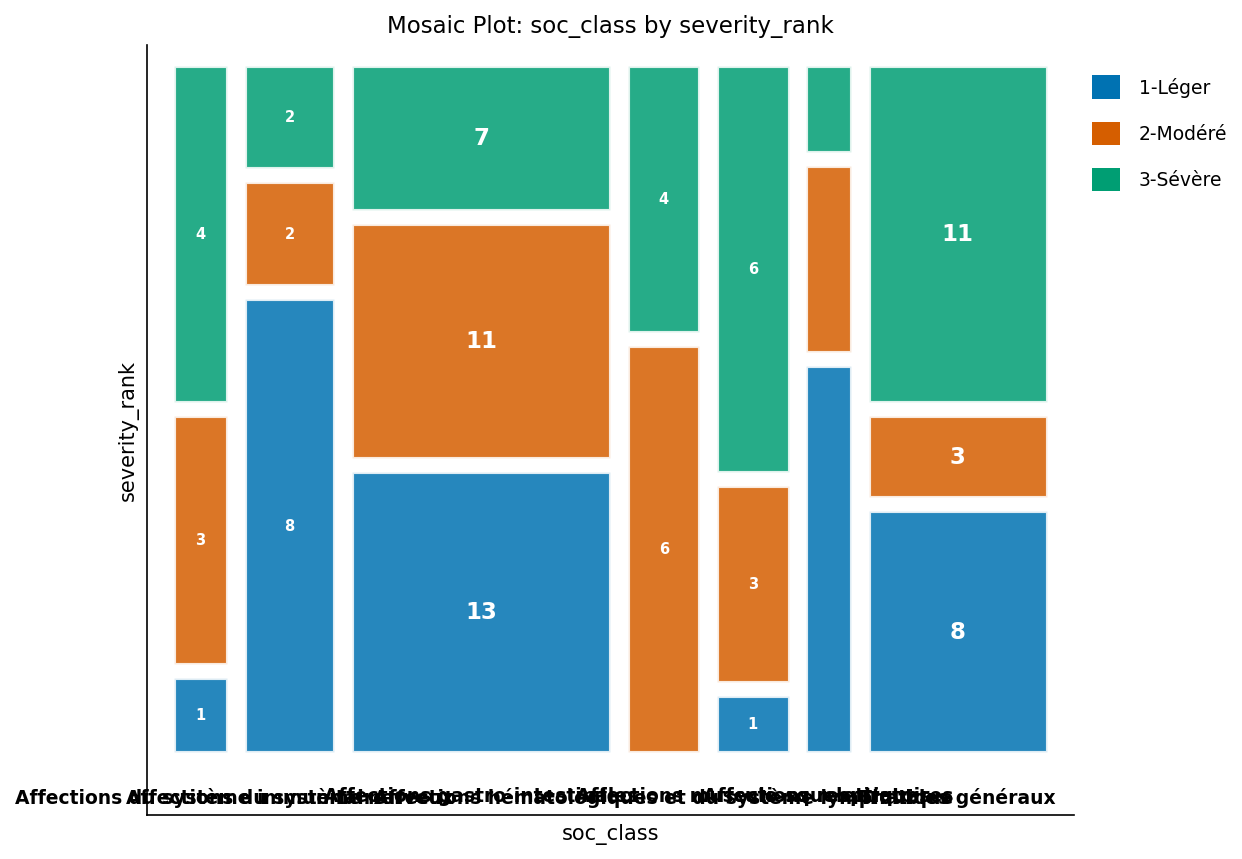

In [7]:
/* --------------------------------------------------------
   Fréquence par SOC selon le bras de traitement
   ODS OUTPUT capture les résultats pour la détection de signal
   -------------------------------------------------------- */
ODS SORTIE onewayfreqs=work.soc_freq_table;

PROCÉDURE FRÉQUENCES DONNÉES=work.ae_coded ORDRE=FRÉQUENCES;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    ÉTIQUETTE soc_class="Classe de systèmes d'organes (SOC)"
          treatment_arm="Bras de traitement"
          severity_rank="Sévérité";
    TITRE "Incidence des EI par classe de systèmes d'organes et bras de traitement";
EXÉCUTER;

ODS SORTIE CLOSE;


                              Événements indésirables graves par SOC et bras de traitement                              

                                                   The FREQ Procedure

Table of Classe de systèmes d'organes (SOC) by Bras de traitement

Classe de systèmes d'organes (SOC)  |COMPARATEUR_ACTIF |     EXPERIMENTAL |          PLACEBO |             Total
------------------------------------+------------------+------------------+------------------+------------------
Affections du système immunitaire   |                0 |                0 |                1 |                 1
------------------------------------+------------------+------------------+------------------+------------------
Troubles généraux                   |                1 |                1 |                1 |                 3
------------------------------------+------------------+------------------+------------------+------------------
Total                               |                1 |      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


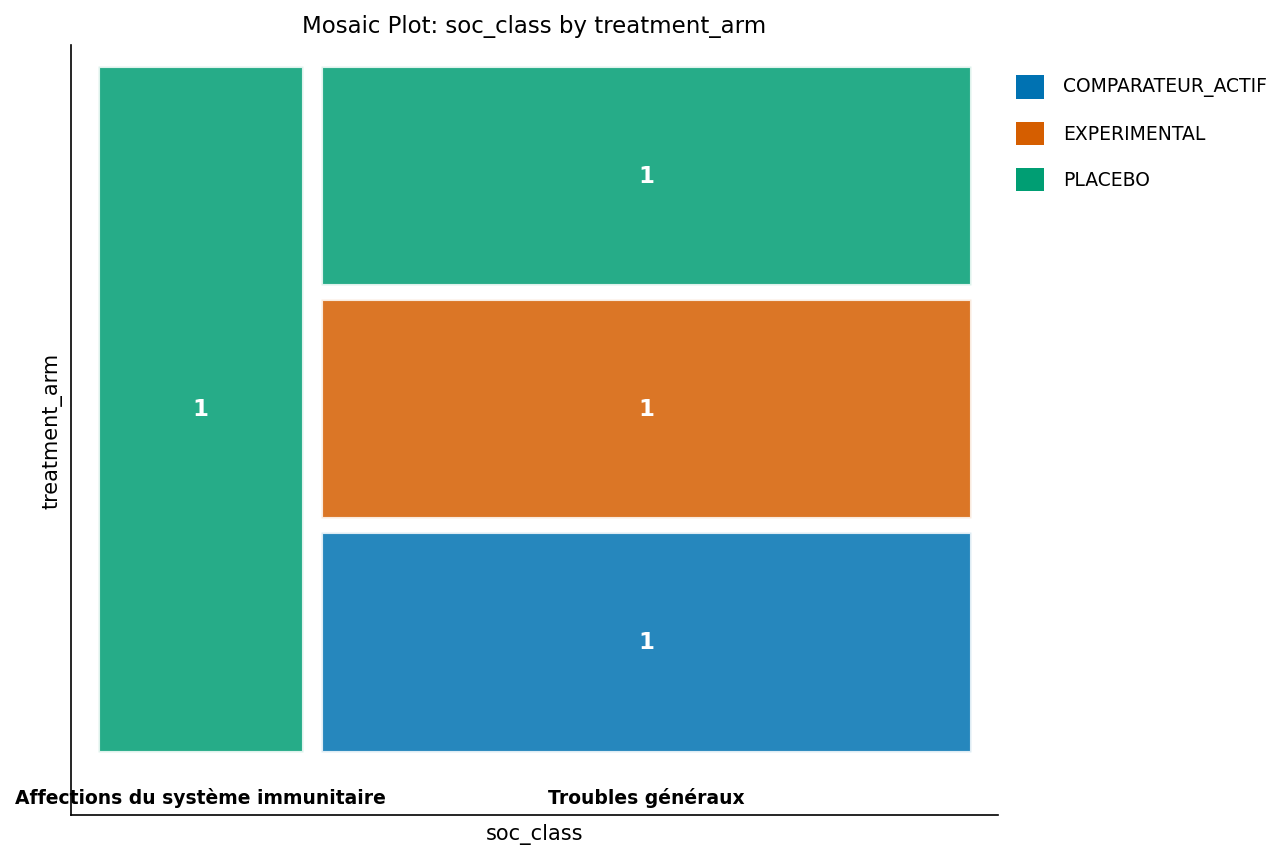

In [8]:
/* --------------------------------------------------------
   Synthèse des EI graves par SOC pour le narratif de sécurité
   -------------------------------------------------------- */
PROCÉDURE FRÉQUENCES DONNÉES=work.ae_coded;
    OÙ aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    ÉTIQUETTE soc_class="Classe de systèmes d'organes (SOC)"
          treatment_arm="Bras de traitement";
    TITRE 'Événements indésirables graves par SOC et bras de traitement';
EXÉCUTER;


---

### Interprétation

Un seul format de valeurs `$pt_to_soc` a codé les 100 événements indésirables à
partir de 12 termes préférés MedDRA verbatim vers 7 classes de systèmes
d'organes (SOC), et ce format unique a piloté chaque tableau ci-dessous sans
avoir à recoder les données.

Par SOC et par sévérité, les **affections gastro-intestinales** forment la
classe la plus fréquente avec 31 des 100 événements (13 légers, 11 modérés, 7
sévères), suivies des **troubles généraux** avec 22 événements. Les autres
classes sont plus petites : affections du système nerveux (12), affections
hématologiques et du système lymphatique (10), affections musculo-squelettiques
(10), affections du système immunitaire (8), et affections respiratoires (7).
Sur l'ensemble des événements, la répartition par sévérité est de 35 légers, 30
modérés et 35 sévères.

Seuls 4 événements ont été signalés comme graves (`aeser='Y'`) : 3 dans les
troubles généraux (un par bras) et 1 dans les affections du système
immunitaire (placebo). Le tableau croisé SOC par bras de traitement est
construit à partir des 12 événements dont le sujet correspondait à un
enregistrement de randomisation, si bien que les effectifs par bras sont
illustratifs plutôt que dimensionnés pour une comparaison entre bras.

Le message clé porte sur le mécanisme du FORMAT, pas sur les chiffres
synthétiques : comme le mappage terme préféré vers SOC réside entièrement dans
PROC FORMAT, le même appel `PUT(aedecod, $pt_to_soc.)` recode l'ensemble du jeu
de données, et la mise à jour vers une nouvelle version du dictionnaire MedDRA
se résume à modifier un seul format plutôt que chaque rapport. ODS OUTPUT a
capturé les fréquences par SOC sous forme de `work.soc_freq_table` pour la
revue de signal en aval.


---

In [9]:
/* --------------------------------------------------------
   Exporter le jeu de données d'EI codé par SOC pour la revue
   de signal de sécurité. Le format unique $pt_to_soc a rempli
   soc_class, le fichier exporté est donc prêt pour l'analyse
   en aval au niveau SOC.
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;



NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>